In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages 
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv
import operator


In [2]:
load_dotenv()

True

In [3]:
llm=ChatGoogleGenerativeAI(
    model='gemini-3.1-flash-lite'
)

In [4]:
class chatstate(TypedDict):
    message: Annotated[list[BaseMessage], add_messages]
    

In [5]:
def chatnode(state: chatstate):
    # take user query from state
    messages=state['message']

    #send to llm
    response=llm.invoke(messages)

    # return response to state
    return {'message': [response]}

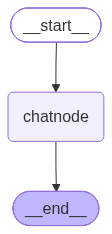

In [12]:
checkpointer=MemorySaver()
graph=StateGraph(chatstate)

#nodes
graph.add_node('chatnode',chatnode)

#edges
graph.add_edge(START,'chatnode')
graph.add_edge('chatnode',END)

#compile
bot=graph.compile(checkpointer=checkpointer)

bot

In [7]:
initial_state={
    'message': [HumanMessage(content='what is the capital of india?')]
}

response=bot.invoke(initial_state)

In [8]:
response['message'][-1].text

'The capital of India is **New Delhi**.'

In [16]:
thread_id='1'

while True:
    user_message=input('Type here: ')
    print('user: ',user_message)

    if user_message.strip().lower() in ['exit','quit','bye']:
        break
    
    config={'configurable':{'thread_id': thread_id}}
    response=bot.invoke({'message':[HumanMessage(content=user_message)]}, config=config)

    print('AI: ', response['message'][-1].text)

user:  what is my name
AI:  Your name is Ankush!
user:  what was the result of our last math problem
AI:  The result of our last math problem (52 multiplied by 3) was **156**.
user:  exit


In [15]:
bot.get_state(config=config)

StateSnapshot(values={'message': [HumanMessage(content='hi my name is ankush ', additional_kwargs={}, response_metadata={}, id='ea2bab22-c028-4fee-9392-4cafd223d7af'), AIMessage(content=[{'type': 'text', 'text': 'Hi Ankush! It’s nice to meet you. How are you doing today? Is there anything I can help you with?', 'extras': {'signature': 'EjQKMgERTTIPNmrrcYYPE9wudzQKIFhDWg01C66pilRJOyOXHSbRXsRfv74zMOxrSG3pEYI6'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f753a-78c6-7691-be9a-870e01945700-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 27, 'total_tokens': 35, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='eb12f63c-1adc-48fb-989e-e56650b9a885'), AIMessage(content=[{'type': 'text', 'text': 'Your name is Ankush!', 'extras': {'sig